In [1]:
from pixell import enmap, enplot
import yaml
import numpy as np

In [2]:
with open("/global/cfs/projectdirs/act/data/mlokken/oriented_stacks/actxdesi/configs/config_stack_actdesi_dr2_tsz.yaml", "r") as f:
    cfg = yaml.safe_load(f)

In [3]:
maskfile_list = cfg["paths"]["mask_file_list"]
maskfile_list

['/global/cfs/cdirs/cmb/data/act_dr6/dr6.02/nilc/published/ilc_footprint_mask.fits',
 '/global/cfs/cdirs/cmb/data/act_dr6/dr6.02/nilc/published/ilc_inpaint_mask.fits',
 '/global/cfs/cdirs/cmb/data/act_dr6/dr6.02/nilc/published/ilc_subtracted_mask.fits']

In [8]:
mask = enmap.read_map( '/global/cfs/cdirs/cmb/data/act_dr6/dr6.02/nilc/published/ilc_inpaint_mask.fits')

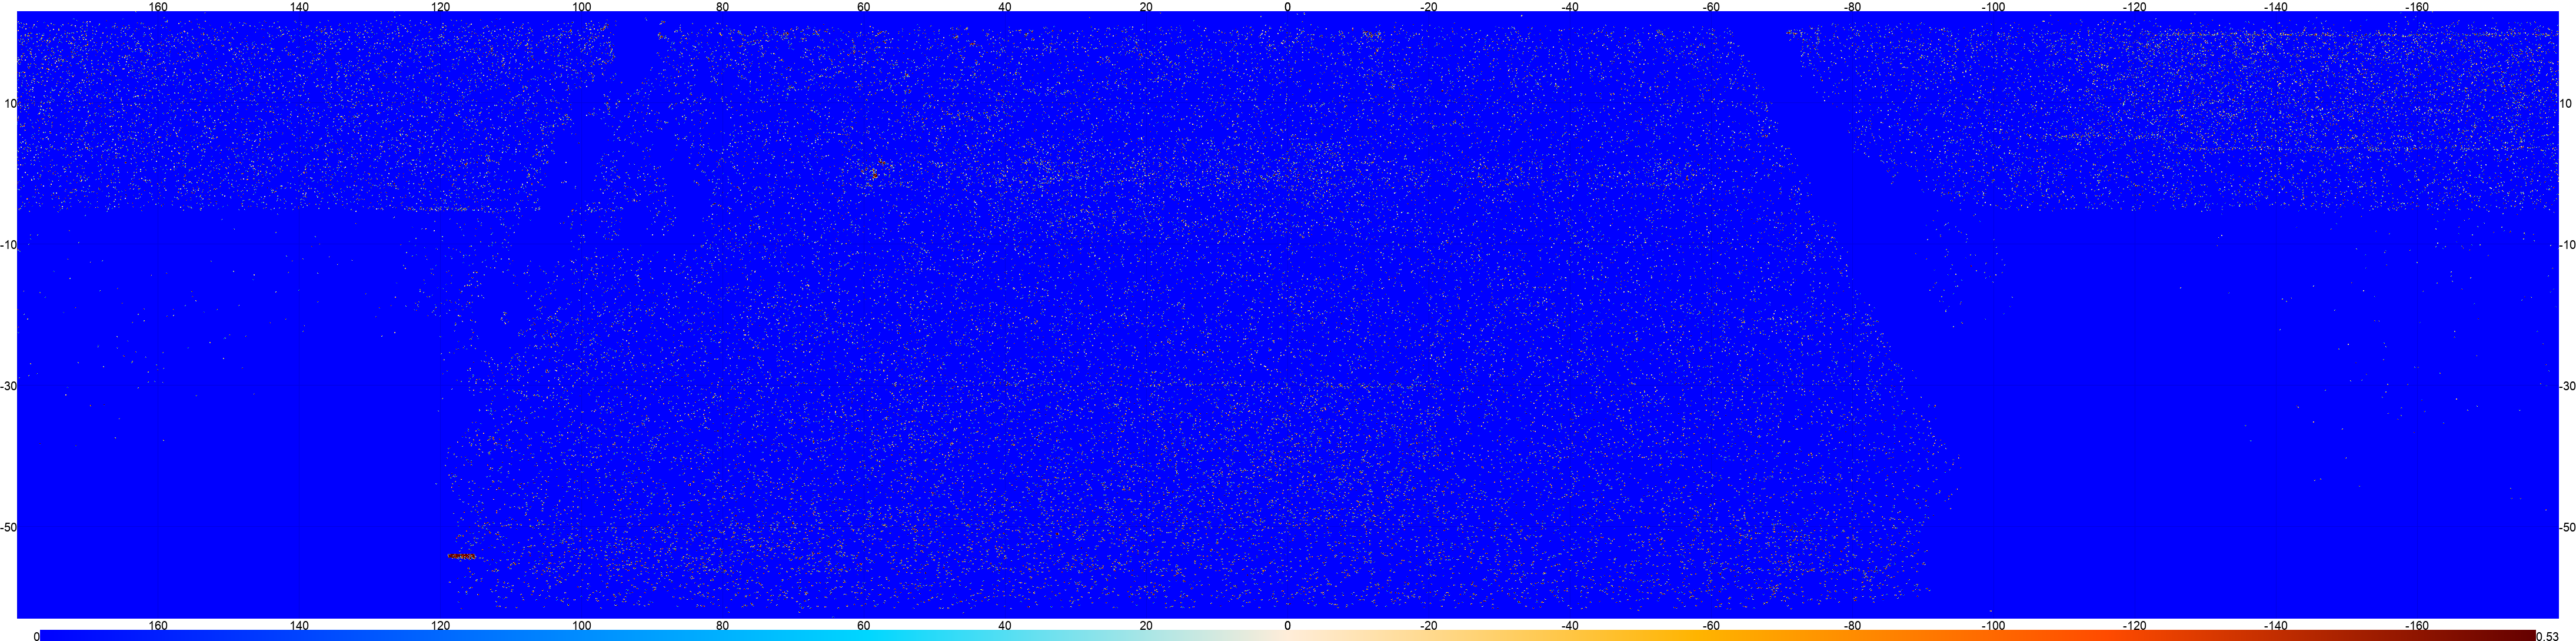

In [5]:
enplot.pshow(mask, colorbar=True, downgrade=10, ticks=20, font_size=20)

In [25]:
import astropy.units as u

Found masks
/global/cfs/cdirs/cmb/data/act_dr6/dr6.02/nilc/published/ilc_footprint_mask.fits
/global/cfs/cdirs/cmb/data/act_dr6/dr6.02/nilc/published/ilc_inpaint_mask.fits
0.0
0


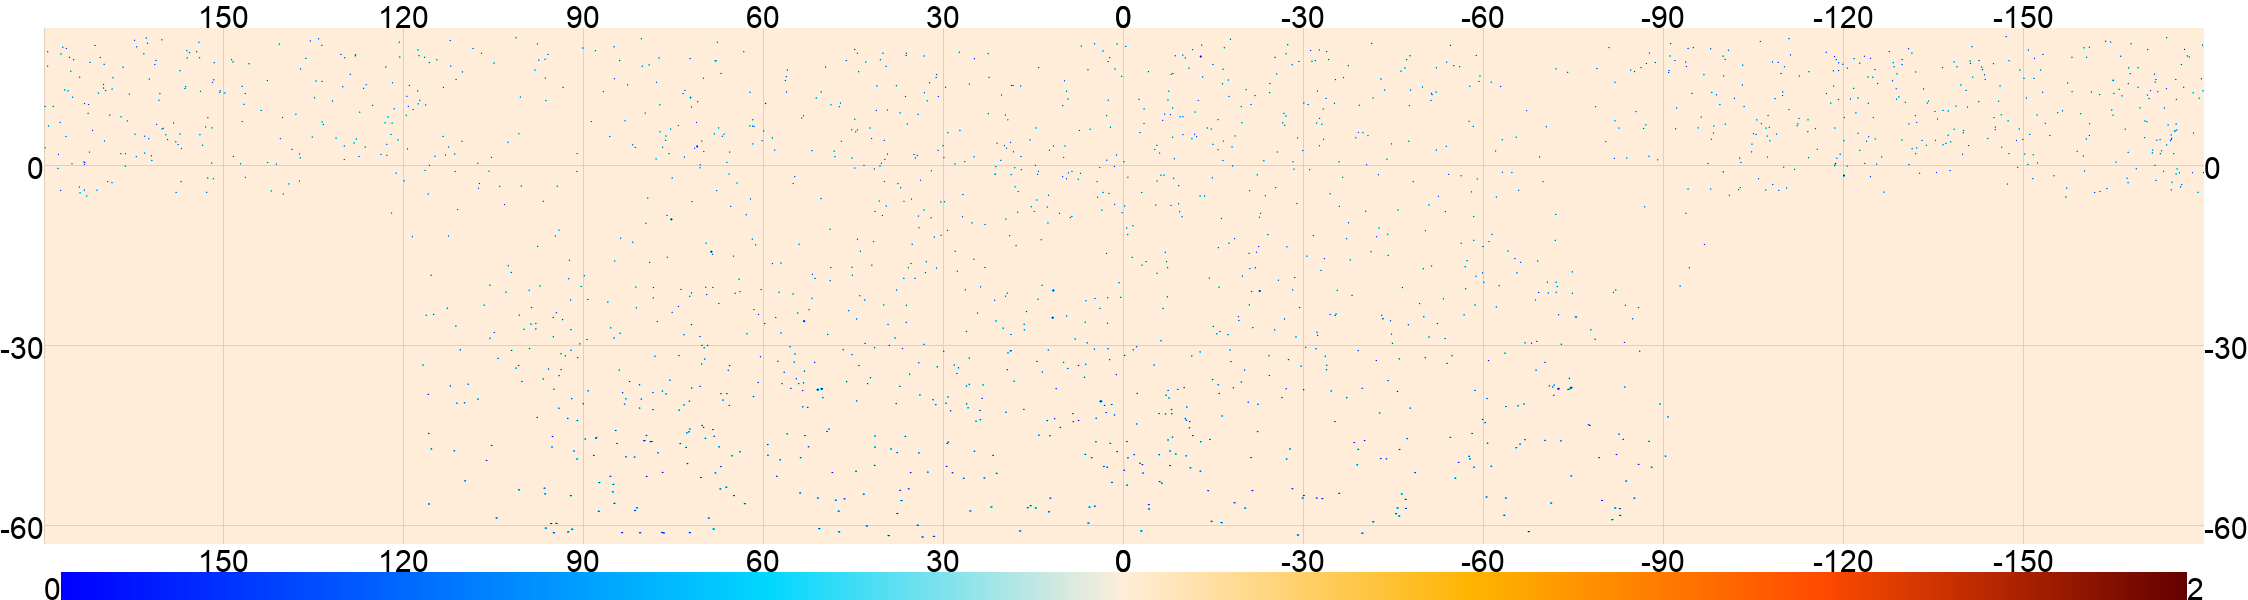

/global/cfs/cdirs/cmb/data/act_dr6/dr6.02/nilc/published/ilc_subtracted_mask.fits
0.0
0


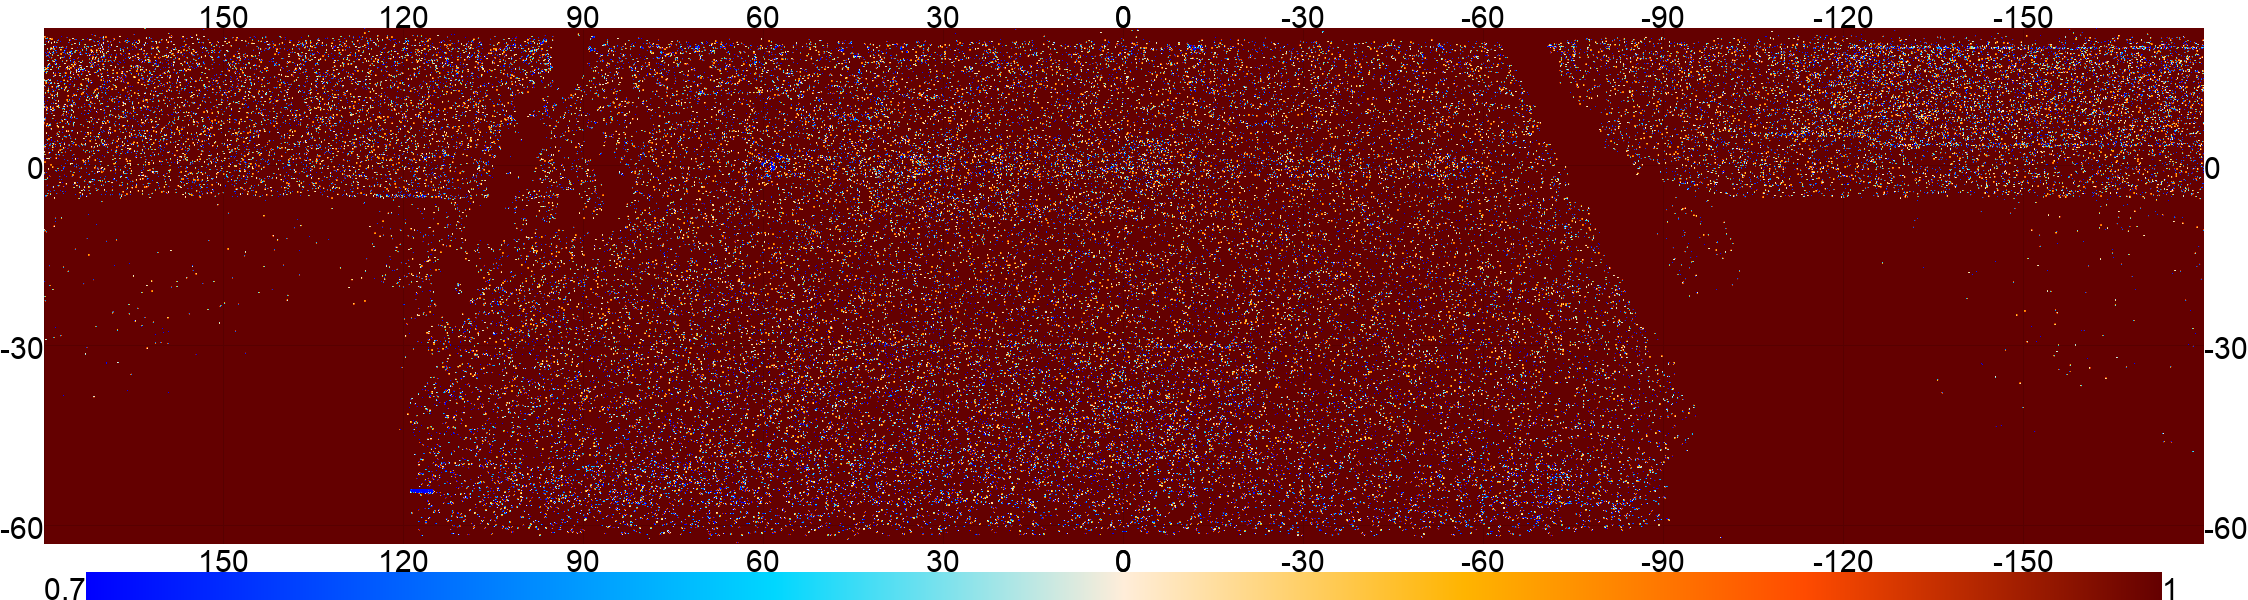

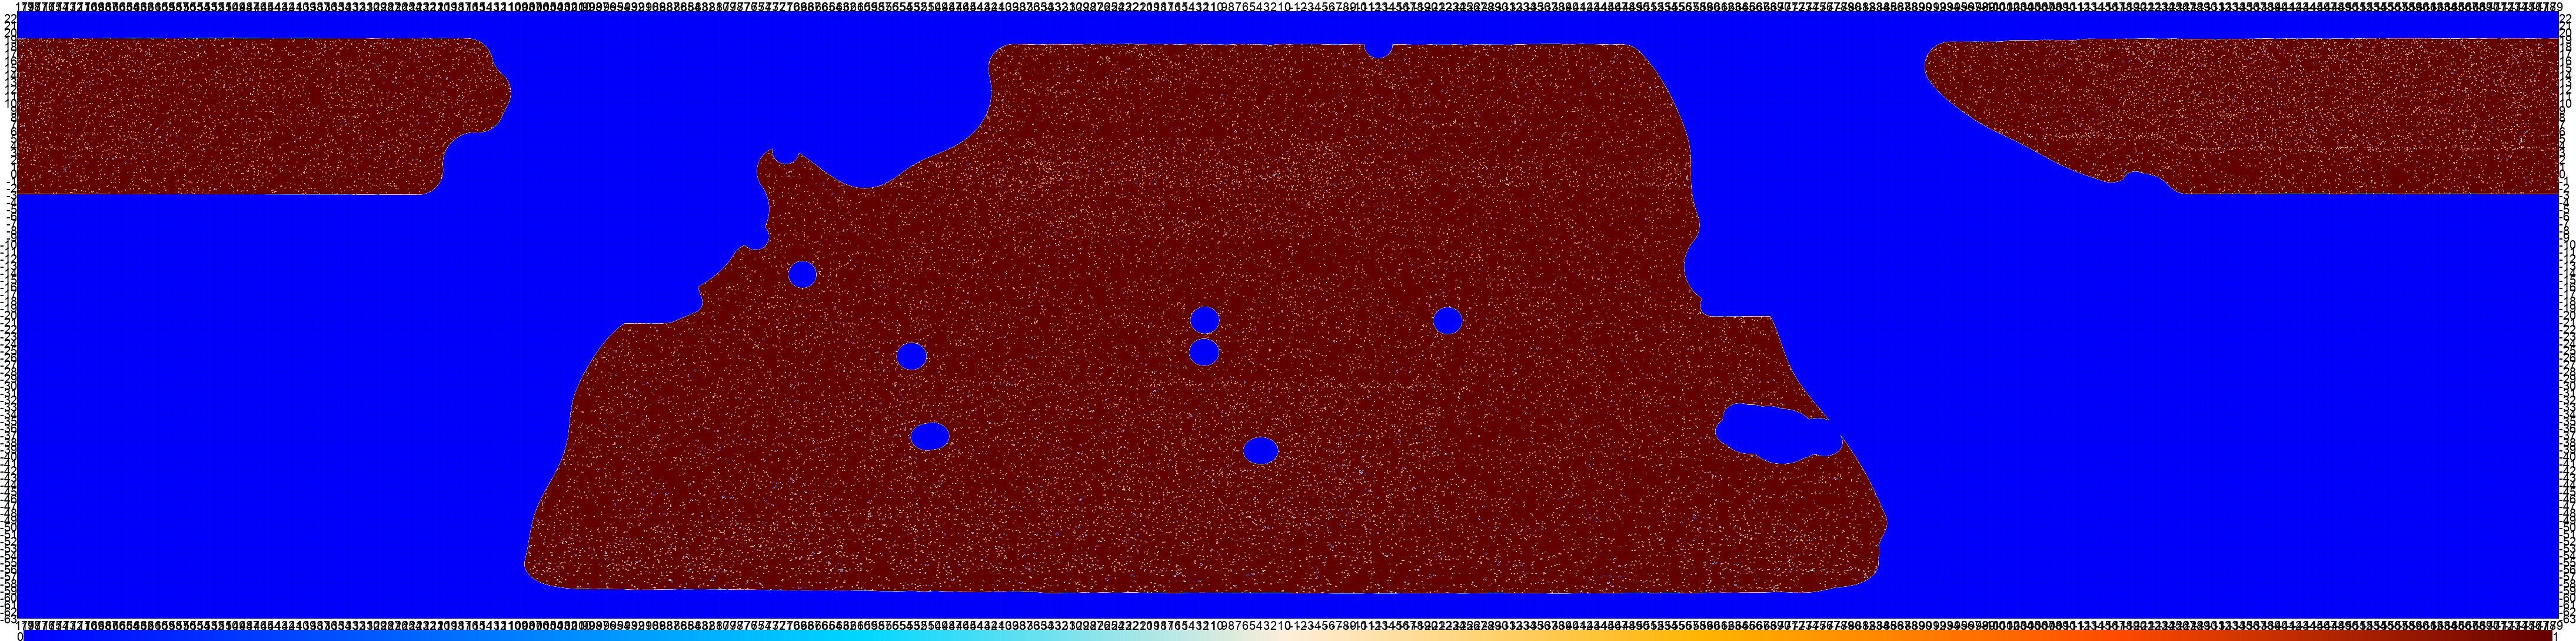

Shrinking mask...


In [26]:
if maskfile_list is not None:
        print("Found masks")
        if maskfile_list[0].endswith("shrunk.fits") and len(maskfile_list)==1:
            maskpath = maskfile_list[0]
        else:
            for i, maskpath in enumerate(maskfile_list):
                print(maskpath)
                try:
                    mask = enmap.read_map(maskpath)
                    if i == 0:
                        # make binary
                        mask[mask<1]=0
                        mask[mask!=0]=1
                        # enplot.pshow(mask, downgrade=20, colorbar=True, ticks=30, font_size=30)
                        combined_mask = mask
                    else:
                        # enplot.pshow(mask, downgrade=10, colorbar=True, ticks=10)
                        newmask = enmap.zeros(mask.shape, mask.wcs)
                        print(np.sum(newmask))
                        newmask[mask<0.01] = 1
                        # make sure newmask is binary
                        print(np.sum((newmask!=0) & (newmask!=1)))
                        enplot.pshow(newmask, downgrade=20, colorbar=True, ticks=30, font_size=30)
                        combined_mask *= newmask

                        
                except Exception as e:
                    raise ValueError(f"Could not read mask file {maskpath}. Please ensure it is enmap format.") from e
        enplot.pshow(combined_mask, downgrade=10, colorbar=True)

        # shrink the True part of the mask the amount given, or by size of the cutouts
        print("Shrinking mask...")
        combined_mask = enmap.shrink_mask(combined_mask, (0.1*u.deg).to(u.rad).value)
        

In [ ]:
combined_mask = enmap.shrink_mask(combined_mask, (0.1*u.deg).to(u.rad).value)


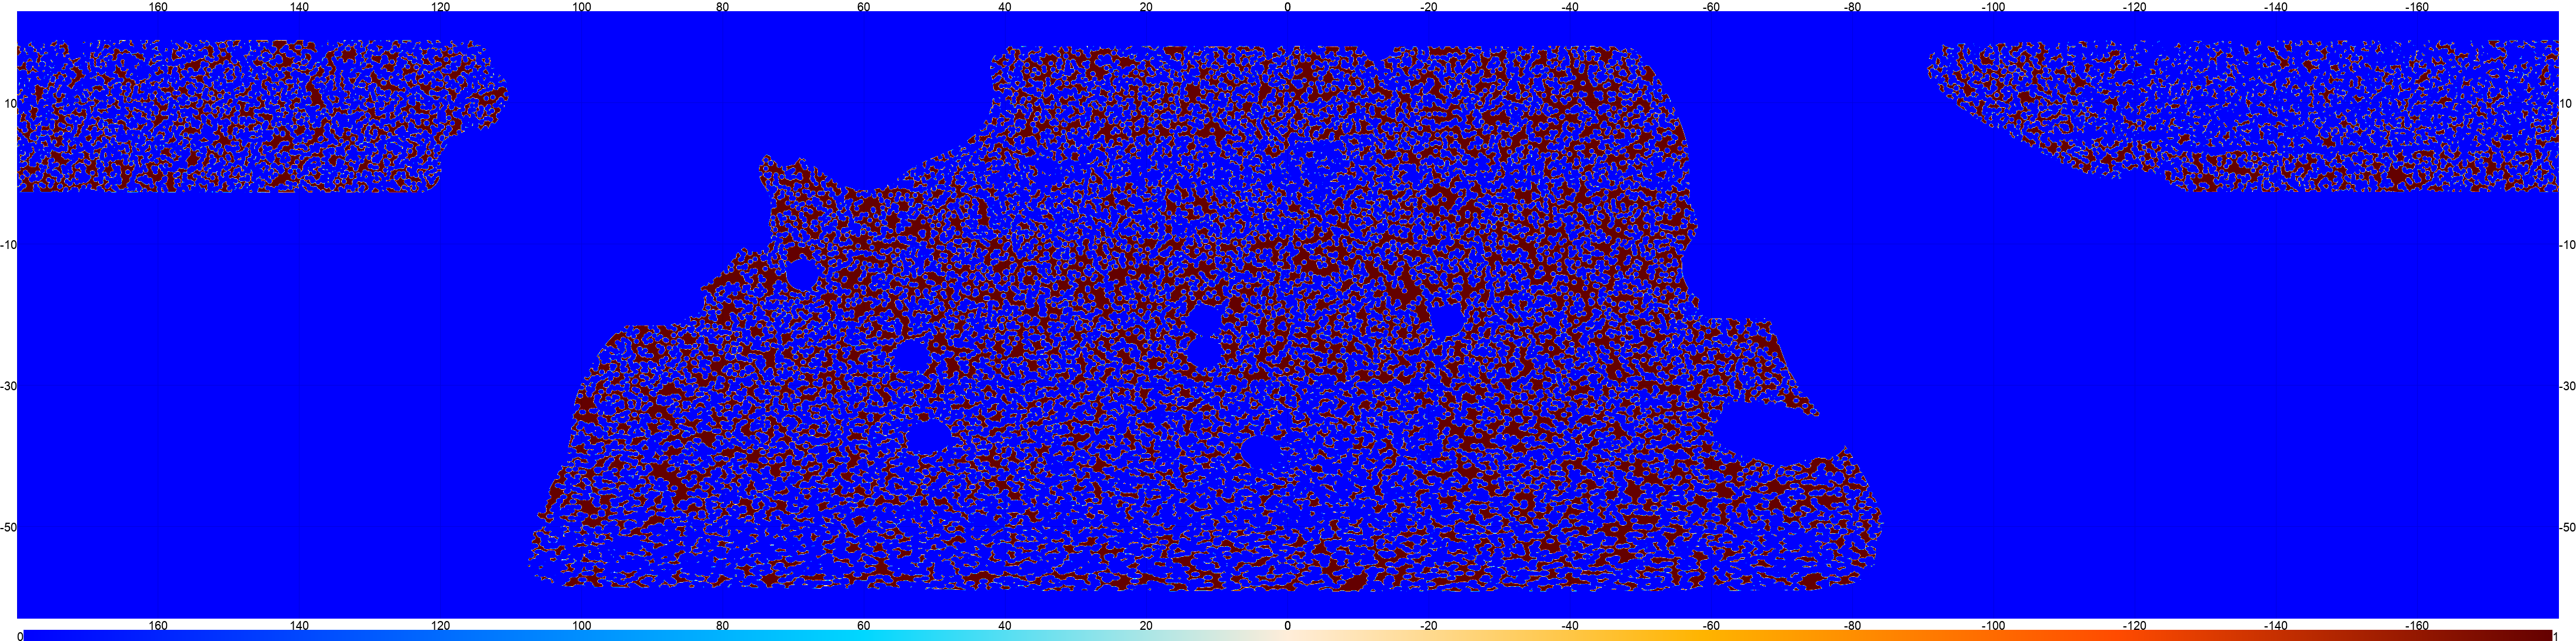

In [27]:
enplot.pshow(combined_mask, downgrade=10, colorbar=True, ticks=20, font_size=20)

In [30]:
# write mask to new file and delete
maskpath = "/pscratch/sd/m/mlokken/actxdesi/act_data/combined_mask_sources_shrunkp3deg.fits"
# # Ensure FITS-compatible binary mask
combined_mask = (combined_mask > 0).astype(np.uint8)
enmap.write_map(maskpath, combined_mask) # error here ML
print("Combined mask written to", maskpath)


Combined mask written to /pscratch/sd/m/mlokken/actxdesi/act_data/combined_mask_sources_shrunkp3deg.fits


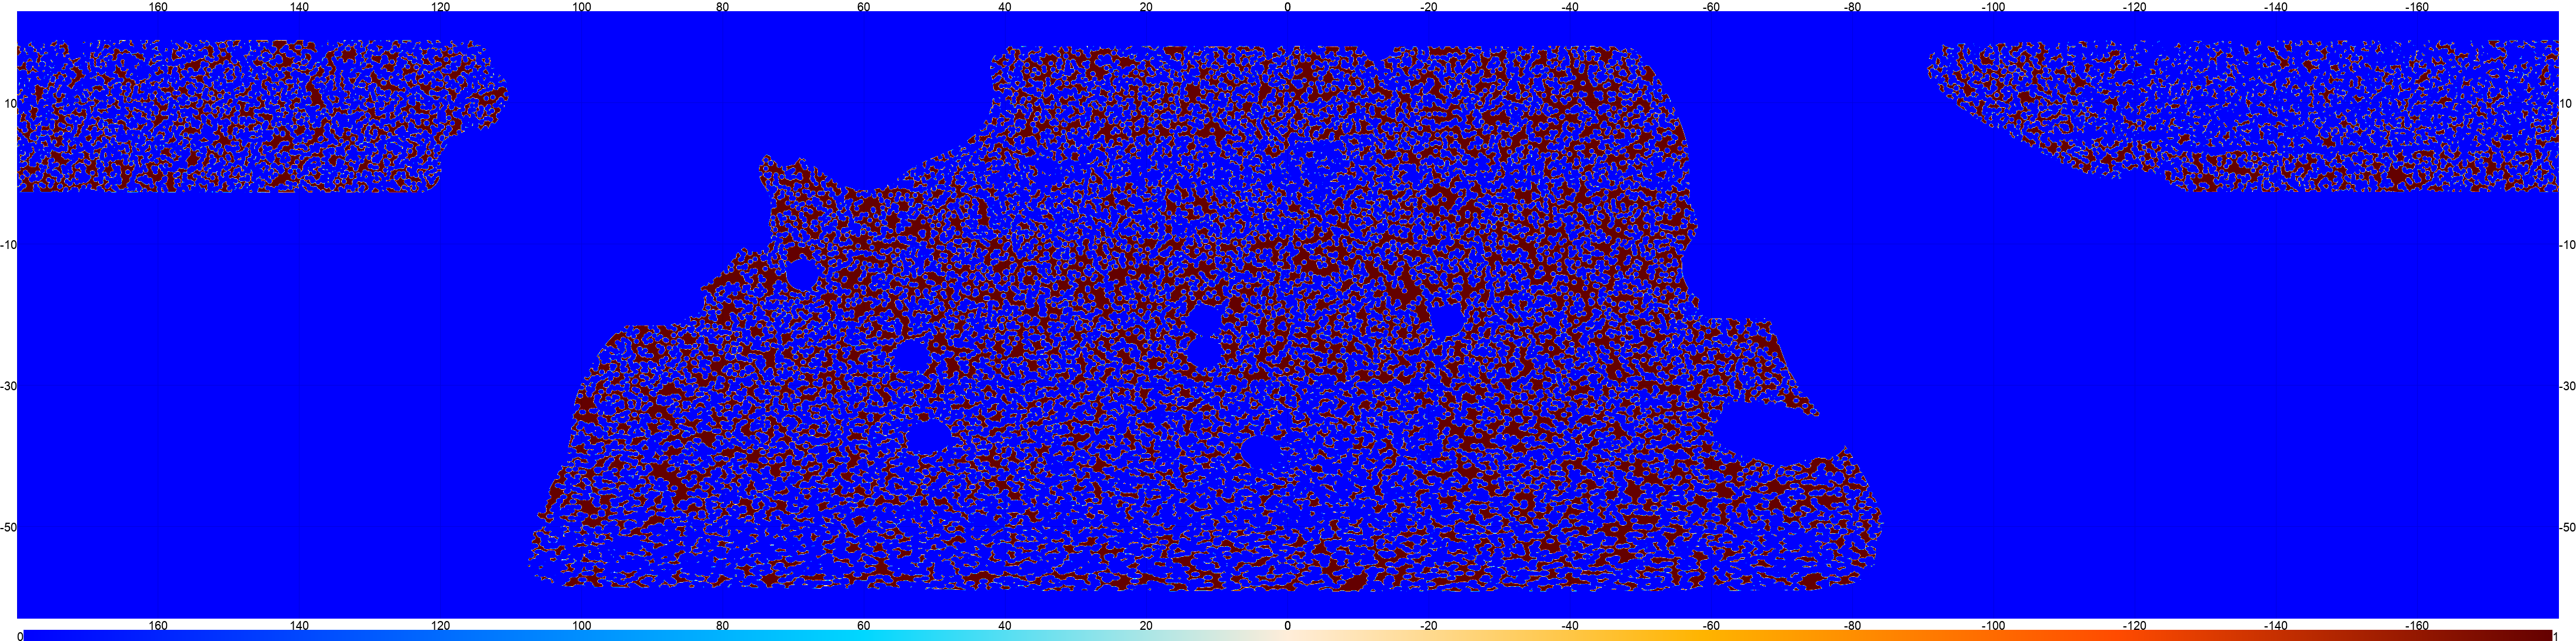

In [31]:
# read in the mask
combined_mask_read = enmap.read_map(maskpath)
enplot.pshow(combined_mask_read, downgrade=10, colorbar=True, ticks=20, font_size=20)